# Lab 11 -- Solving the XOR Problem (using multiple perceptrons)

#### Author: Esraaj Sarkar Gupta
#### Date: 11th April, 2026

In [1]:
# ---- Imports ---- #
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

import matplotlib.pyplot as plt

print("Imports completed with errors!")

# ---- Courteous Greeting ---- #
# Good evening Indrani ma'am, I hope you're having a good week! :D
# There was so much code this time around </3

2026-04-12 05:51:18.837335: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-12 05:51:19.118097: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-12 05:51:20.255858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Imports completed with errors!


In [2]:
# ---- XOR Data ---- #
X : np.ndarray = np.array([[0,0],[1,0],[0,1],[1,1]])    # This seemed like a neat pick :3
y : np.array = np.array([0,1,1,0])

# Author's Note (1/1)
# (Removed)

# Debuggiung material
print(X.shape)  # <-- I needed to confirm the 2

(4, 2)


In [3]:
# ==== Functions Block ===== #

# ---- Learning Rate Callback -- used for plotting ---- #
class LearningRateCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.learning_rates = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.Variable) or tf.is_tensor(lr):
            lr = float(lr.numpy())
        else:
            lr = float(lr)
        self.learning_rates.append(lr)

# ---- Building Neural Network ---- #
def build_model(
    learning_rate : float = 0.24,   # Some would prefer 0.3, but 0.24 is close enough!
    momentum : float = 0.0
):  
    # -- Build a sequential model, layer by layer -- #
    model = Sequential()

    # Build n = 8 hidden layers
    model.add(
        Dense(
            8,                          # Create 8 neurons
            input_dim = X.shape[1],     # shape (2)
            activation = "relu"         # ReLU -- Rectified Linear Unit
        )
    )
    """
    More about ReLU:
        Rectified Linear Unit -- Outputs input if positive, 0 if negative.
        This non-linearity allows the network to bend in the non-linear feature space.
    """

    # Output Layer
    model.add(
        Dense(
            1,                      # Only one output layer is required (binary classification)
            activation = "sigmoid"  # Sigmoid function 
        )
    )

    # Optimizer -- using SGD
    optimizer = SGD(
        learning_rate = learning_rate,      # You can guess what this hyperparameter is supposed to be
        momentum = momentum
    )

    # Compile -- Attach model architecture to the optmizer
    model.compile(
        optimizer = optimizer,
        loss = "mse"            # Mean Squared Error
    )

    # Pass it back <3
    return model

# ---- Plotting Results ---- #
def plot_results(losses, lrs, title_prefix):
    epochs = len(losses)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot 1: Change of MSE over time
    ax1.plot(range(1, epochs + 1), losses, color='teal')
    ax1.set_title(f'No. of Epochs to Convergence: {epochs}')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Sum of Squared Error (SSE)')
    
    # Plot 2: Learning rate over time
    ax2.plot(range(1, len(lrs) + 1), lrs, color='teal')
    ax2.set_title(f'{title_prefix} - Learning Rate vs. Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Learning Rate')
    
    plt.tight_layout()
    plt.show()

---- Experiment :: Standard Stochastic Gradient Descent ---- 


/home/esraaj/jupyterenv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-12 05:51:21.557959: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


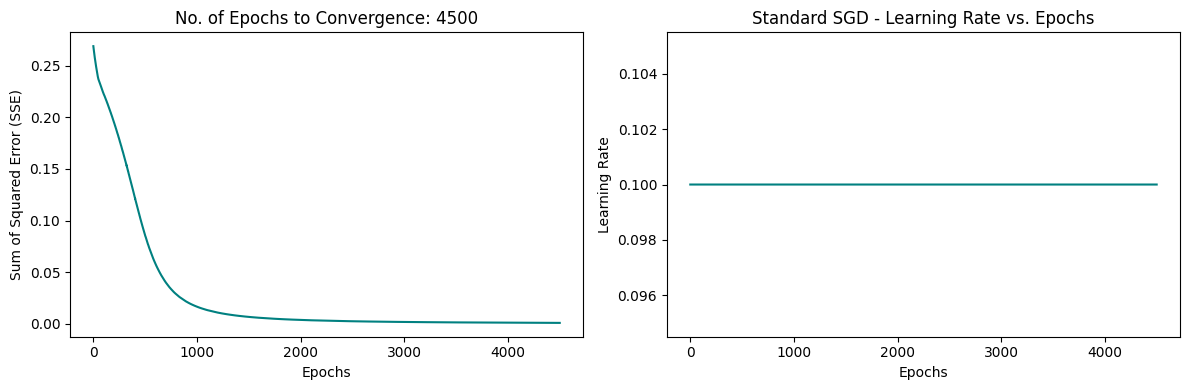

In [4]:
# ---- Experiment 1 -- SGD, without momentum ---- #
print("---- Experiment :: Standard Stochastic Gradient Descent ---- ")
model = build_model(learning_rate = 0.10)

# Flag
converged : bool = False
target_loss : float = 0.001
losses : list = list([])
lr_callback = LearningRateCallback()

# Training Loop

while not converged:
    history = model.fit(
        X,
        y,
        epochs = 10,                # 
        verbose = 0,                # Shush
        callbacks=[lr_callback]     # Record callbacks
    )

    losses.extend(history.history['loss'])
    if losses[-1] <= target_loss:
        converged = True

plot_results(losses, lr_callback.learning_rates, "Standard SGD")


---- Experiment :: Stochastic Gradient Descent ---- 


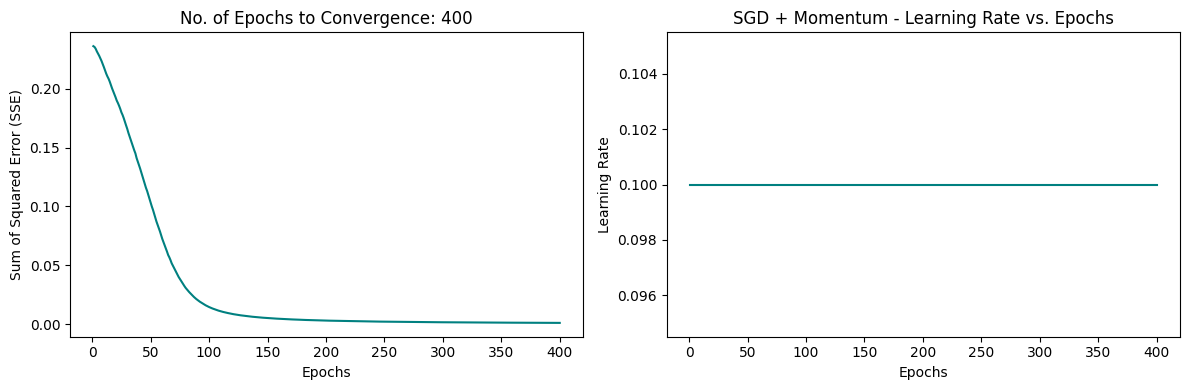

In [5]:
# ---- Experiment 2 -- SGD, with momentum ---- #
print("---- Experiment :: Stochastic Gradient Descent ---- ")
model = build_model(learning_rate = 0.10, momentum = 0.9)

# Flag
converged : bool = False
target_loss : float = 0.001
losses : list = list([])
lr_callback = LearningRateCallback()

# Training Loop

while not converged:
    history = model.fit(
        X,
        y,
        epochs = 10,                # 
        verbose = 0,                # Shush
        callbacks=[lr_callback]     # Record callbacks
    )

    losses.extend(history.history['loss'])
    if losses[-1] <= target_loss:
        converged = True

plot_results(losses, lr_callback.learning_rates, "SGD + Momentum")

---- Experiment :: Stochastic Gradient Descent ---- 


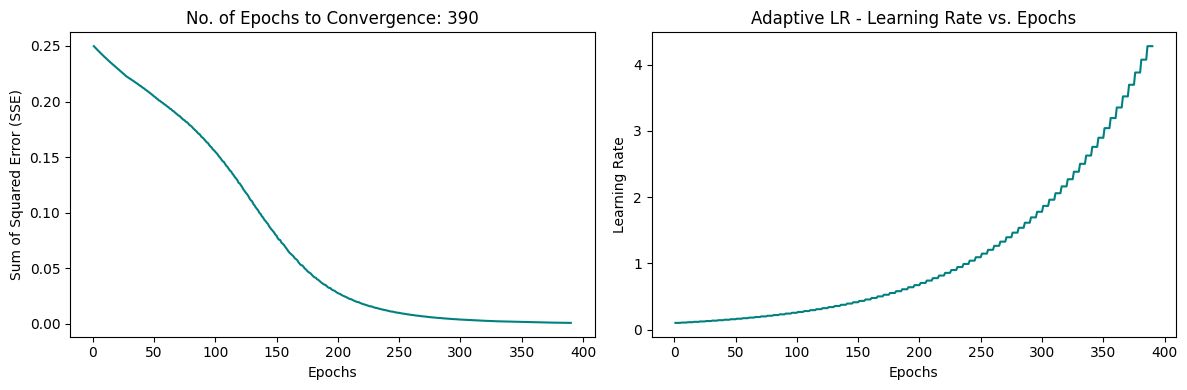

In [6]:
# ---- Experiment 3 -- SGD, adaptive alpha ---- #
print("---- Experiment :: Stochastic Gradient Descent ---- ")
model = build_model(learning_rate = 0.10, momentum = 0.0)

# Flag
converged : bool = False
target_loss : float = 0.001
losses : list = list([])
lr_callback = LearningRateCallback()
prev_loss : float = float('inf')

# Training Loop

while not converged:
    history = model.fit(
        X,
        y,
        epochs = 5,                 # 
        verbose = 0,                # Shush
        callbacks=[lr_callback]     # Record callbacks
    )

    losses.extend(history.history['loss'])
    current_loss = losses[-1]

    # Given Heuristic Logic
    current_lr = float(
        model.optimizer.learning_rate.numpy()
    )

    # I do as the giants say:
    if current_loss > prev_loss * 1.04:
        new_lr = current_lr * 0.7 
        model.optimizer.learning_rate.assign(new_lr)

    elif current_loss < prev_loss:
        new_lr = current_lr * 1.05 
        model.optimizer.learning_rate.assign(new_lr)
        
    prev_loss = current_loss

    # Quick check :D
    if current_loss <= target_loss:
            converged = True

plot_results(losses, lr_callback.learning_rates, "Adaptive LR")

---- Experiment :: Stochastic Gradient Descent ---- #


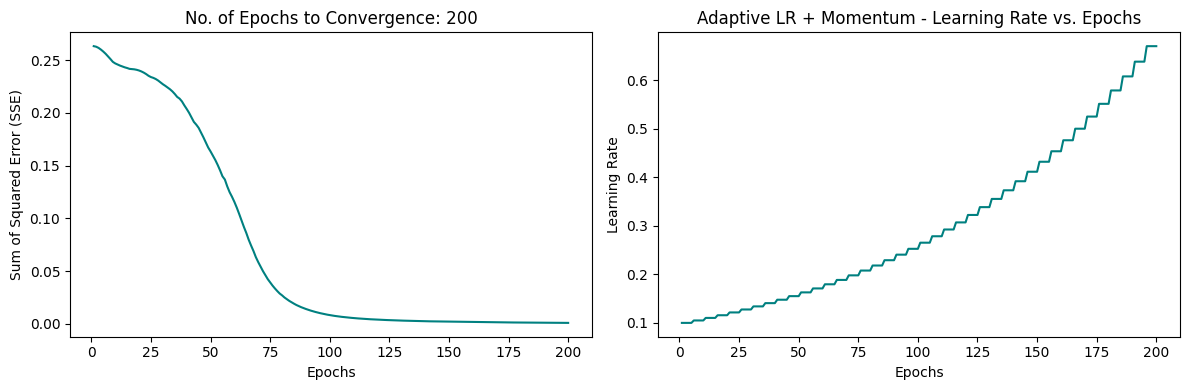

In [7]:
# ---- Experiment 4 -- SGD, adaptive alpha ---- #
print("---- Experiment :: Stochastic Gradient Descent ---- #")
model = build_model(learning_rate = 0.10, momentum = 0.9)

# Flag
converged : bool = False

target_loss : float = 0.001
losses : list = list([])
lr_callback = LearningRateCallback()
prev_loss : float = float('inf')

while not converged:
    history = model.fit(
        X,
        y,
        epochs=5,               #
        verbose=0,              #
        callbacks=[lr_callback] #
    )

    losses.extend(history.history['loss'])
    current_loss = losses[-1]
    
    current_lr = float(
        model.optimizer.learning_rate.numpy()
    )

    # As you say, sire:
    if current_loss > prev_loss * 1.04:
        new_lr = current_lr * 0.7
        model.optimizer.learning_rate.assign(new_lr)

    elif current_loss < prev_loss:
        new_lr = current_lr * 1.05
        model.optimizer.learning_rate.assign(new_lr)
        
    prev_loss = current_loss
    
    if current_loss <= target_loss:
        converged = True

plot_results(losses, lr_callback.learning_rates, "Adaptive LR + Momentum")

In [8]:
# And thus the experiments conclude.
# Conclusive conclusions (and such).

# Report

#### Question 1
A single perceptron can only classify data that is linearly separable. XOR outputs alternate across the input space, making it mathematically impossible to separate them using a single line. A multilayer network solves this problem by using a hidden layer with non-linear activation functions (here, ReLU), which tranforms and projects the 2D input data to a higher dimensional space where it is linearly separable. This allows the final perceptron to linearly separate (and thus classify) the data.

#### Question 2
In a backpropagation neural network, the middle layers are called hidden since their specific inputs and outputs are "hidden" from the user, and from the external dataset. The intermediate layers "learn" underlying features and representations that the network uses to make a final decision. The user may only supervise the raw data that is input into the layers and the output from the final layer.

#### Question 3
* <b> Model Parameters </b> are internal variables (the weights and biases) that the algorithm automatically learns and updates during the training process.

* The <b> Hyperparameters </b> are the external model configuration settings that are selected by the model engineer (such as myself, and I'm proud of myself :D). These are defined before the model is trained (as opposed to during training) and are typically chosen such that the model trains faster, and more efficiently.

#### Question 4
Standard backpropagation that utlizes (some form of) gradient descent calculates the slope of the error and takes a step "downward" in the parameter space with steps propotionate to the magnitude of the learning rate $\alpha$. However, this can be slow, and the optimizer can get stuck in valleys in the parameter space. In place of standard gradient descent, one may use accelerated learning techniques (am example of which is momentum or an adaptive learing rate, of which both technqiues have been applied here.) to speed up this process, or in other cases prevent the optimizer from getting stuck in local minima.

#### Question 5
The two heuristics applied for an adaptive learning rate have been given below.
```
Algorithm: Adaptive Learning Rate Update

Inputs:
  current_error  : Sum of Squared Error (SSE) at current epoch
  previous_error : Sum of Squared Error (SSE) at previous epoch
  learning_rate  : The active learning rate

Output:
  learning_rate  : The updated learning rate

Begin:
    // Heuristic 1: If the error spikes by more than 4%, decrease the learning rate
    If current_error > (1.04 * previous_error) Then
        learning_rate = learning_rate * 0.7
        
    // Heuristic 2: If the error improves, increase the learning rate
    Else If current_error < previous_error Then
        learning_rate = learning_rate * 1.05
        
    End If
    
    Return learning_rate
End
```


